In [4]:
%pip install numpy torch torchvision gymnasium[atari,accept-rom-license] opencv-python import_ipynb --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached https://download.pytorch.org/whl/markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Using c

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\Suryansh\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\sympy\\parsing\\autolev\\_antlr\\autolevlexer.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install intel-openmp

   ---------------------------------------- 0.0/30.7 MB ? eta -:--:--
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --------------------------------------- 0.5/30.7 MB 8.5 MB/s eta 0:00:04
    --


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
"""
Main training loop.
Handles environment interaction, agent learning,
logging, and checkpoint saving.
"""

import numpy as np
from config import Config
from env import make_env
from agent import DoubleDQNAgent


def train():
    """
    Run the full training loop:
      1. Create environment and agent.
      2. For each step:
         a. Select action (epsilon-greedy).
         b. Step environment.
         c. Store transition.
         d. Call agent.learn() if enough samples.
         e. Sync target network periodically.
         f. Log episode rewards.
         g. Save checkpoints.
    """
    config = Config()

    # ----- setup -----
    env, preprocessor, stacker = make_env(
        config.ENV_NAME, config.FRAME_SIZE, config.FRAME_STACK
    )
    n_actions = env.action_space.n
    device = "cuda" if __import__("torch").cuda.is_available() else "cpu"

    agent = DoubleDQNAgent(
        n_frames=config.FRAME_STACK,
        n_actions=n_actions,
        config=config,
        device=device,
    )

    # ----- metrics -----
    episode_rewards = []
    episode_reward = 0.0
    episode_count = 0
    losses = []

    # ----- initial reset -----
    obs, info = env.reset()
    state = stacker.reset(preprocessor.process(obs))
    # ----- training loop -----
    for step in range(1, config.TOTAL_STEPS + 1):
    
        # Select action
        action = agent.select_action(state)
    
        # Environment step
        next_obs, reward, terminated, truncated, info = env.step(action)
    
        done = terminated or truncated
    
        # Preprocess next observation
        processed_next = preprocessor.process(next_obs)
    
        # Update frame stack
        next_state = stacker.append(processed_next)
    
        # Store transition
        agent.store_transition(
            state,
            action,
            reward,
            next_state,
            done
        )
    
        # Learn
        loss = agent.learn()
    
        if loss is not None:
            losses.append(loss)
    
        # Update episode reward
        episode_reward += reward
    
        # Move to next state
        state = next_state
    
        # Episode finished
        if done:
    
            episode_rewards.append(episode_reward)
            episode_count += 1
    
            if episode_count % 10 == 0:
    
                avg_reward = np.mean(
                    episode_rewards[-10:]
                )
    
                avg_loss = (
                    np.mean(losses[-100:])
                    if len(losses) > 0
                    else 0.0
                )
    
                print(
                    f"Episode {episode_count} | "
                    f"Step {step} | "
                    f"Avg Reward: {avg_reward:.2f} | "
                    f"Avg Loss: {avg_loss:.4f}"
                )
    
            # Reset environment
            obs, info = env.reset()
    
            state = stacker.reset(
                preprocessor.process(obs)
            )
    
            episode_reward = 0.0
    
        # Save checkpoint
        if step % config.SAVE_INTERVAL == 0:
    
            checkpoint_path = (
                f"checkpoint_{step}.pth"
            )
    
            agent.save(checkpoint_path)
    
            print(
                f"Checkpoint saved: "
                f"{checkpoint_path}"
            )

In [2]:
import torch
print("Is CUDA available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
if __name__ == "__main__":
    rewards = train()

Episode 10 | Step 17860 | Avg Reward: 1.20 | Avg Loss: 0.1585
Episode 20 | Step 35720 | Avg Reward: -2.20 | Avg Loss: 0.4488
Checkpoint saved: checkpoint_50000.pth
Episode 30 | Step 53580 | Avg Reward: -0.50 | Avg Loss: 0.3887
Episode 40 | Step 71440 | Avg Reward: 0.30 | Avg Loss: 0.2914
Episode 50 | Step 89300 | Avg Reward: -1.40 | Avg Loss: 0.3756
Checkpoint saved: checkpoint_100000.pth
Episode 60 | Step 107160 | Avg Reward: -5.70 | Avg Loss: 0.3872
Episode 70 | Step 125020 | Avg Reward: -2.90 | Avg Loss: 0.3058
Episode 80 | Step 142880 | Avg Reward: -3.60 | Avg Loss: 0.3958
Checkpoint saved: checkpoint_150000.pth
Episode 90 | Step 160740 | Avg Reward: -1.10 | Avg Loss: 0.2535
Episode 100 | Step 178600 | Avg Reward: -5.40 | Avg Loss: 0.1934
Episode 110 | Step 196460 | Avg Reward: 4.10 | Avg Loss: 0.1948
Checkpoint saved: checkpoint_200000.pth
Episode 120 | Step 214320 | Avg Reward: -0.90 | Avg Loss: 0.1133
Episode 130 | Step 232180 | Avg Reward: -4.40 | Avg Loss: 0.1035
Checkpoint sa

In [5]:
%pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.3 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 2.7 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.9 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 3.5 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


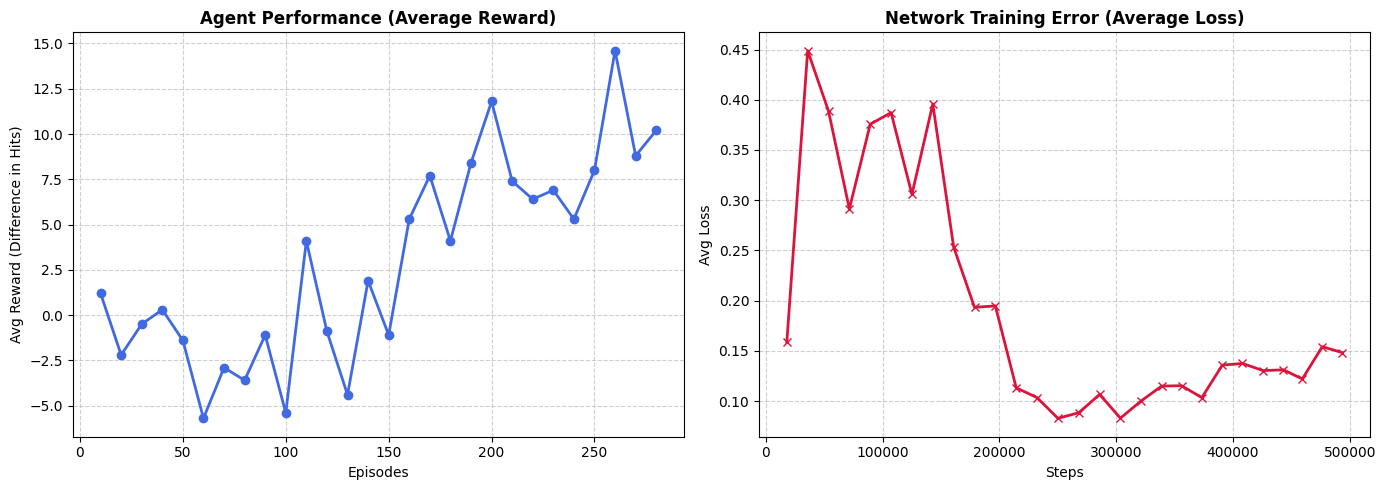

In [8]:
import re
import matplotlib.pyplot as plt

# 1. Paste your printed logs inside these triple quotes:
log_data = """

Episode 10 | Step 17860 | Avg Reward: 1.20 | Avg Loss: 0.1585
Episode 20 | Step 35720 | Avg Reward: -2.20 | Avg Loss: 0.4488
Episode 30 | Step 53580 | Avg Reward: -0.50 | Avg Loss: 0.3887
Episode 40 | Step 71440 | Avg Reward: 0.30 | Avg Loss: 0.2914
Episode 50 | Step 89300 | Avg Reward: -1.40 | Avg Loss: 0.3756
Episode 60 | Step 107160 | Avg Reward: -5.70 | Avg Loss: 0.3872
Episode 70 | Step 125020 | Avg Reward: -2.90 | Avg Loss: 0.3058
Episode 80 | Step 142880 | Avg Reward: -3.60 | Avg Loss: 0.3958
Episode 90 | Step 160740 | Avg Reward: -1.10 | Avg Loss: 0.2535
Episode 100 | Step 178600 | Avg Reward: -5.40 | Avg Loss: 0.1934
Episode 110 | Step 196460 | Avg Reward: 4.10 | Avg Loss: 0.1948
Episode 120 | Step 214320 | Avg Reward: -0.90 | Avg Loss: 0.1133
Episode 130 | Step 232180 | Avg Reward: -4.40 | Avg Loss: 0.1035
Episode 140 | Step 250040 | Avg Reward: 1.90 | Avg Loss: 0.0829
Episode 150 | Step 267900 | Avg Reward: -1.10 | Avg Loss: 0.0885
Episode 160 | Step 285760 | Avg Reward: 5.30 | Avg Loss: 0.1067
Episode 170 | Step 303538 | Avg Reward: 7.70 | Avg Loss: 0.0831
Episode 180 | Step 321388 | Avg Reward: 4.10 | Avg Loss: 0.1003
Episode 190 | Step 338855 | Avg Reward: 8.40 | Avg Loss: 0.1150
Episode 200 | Step 355908 | Avg Reward: 11.80 | Avg Loss: 0.1154
Episode 210 | Step 373278 | Avg Reward: 7.40 | Avg Loss: 0.1035
Episode 220 | Step 390833 | Avg Reward: 6.40 | Avg Loss: 0.1359
Episode 230 | Step 408097 | Avg Reward: 6.90 | Avg Loss: 0.1375
Episode 240 | Step 425780 | Avg Reward: 5.30 | Avg Loss: 0.1304
Episode 250 | Step 443180 | Avg Reward: 8.00 | Avg Loss: 0.1312
Episode 260 | Step 459311 | Avg Reward: 14.60 | Avg Loss: 0.1221
Episode 270 | Step 476432 | Avg Reward: 8.80 | Avg Loss: 0.1542
Episode 280 | Step 493711 | Avg Reward: 10.20 | Avg Loss: 0.1483
"""

# 2. Extract values using regular expressions
episodes = [int(x) for x in re.findall(r"Episode (\d+)", log_data)]
steps = [int(x) for x in re.findall(r"Step (\d+)", log_data)]
rewards = [float(x) for x in re.findall(r"Avg Reward: ([\d.-]+)", log_data)]
losses = [float(x) for x in re.findall(r"Avg Loss: ([\d.]+)", log_data)]

# 3. Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Rewards
ax1.plot(episodes, rewards, marker='o', linestyle='-', color='royalblue', linewidth=2)
ax1.set_title("Agent Performance (Average Reward)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Episodes", fontsize=10)
ax1.set_ylabel("Avg Reward (Difference in Hits)", fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
ax2.plot(steps, losses, marker='x', linestyle='-', color='crimson', linewidth=2)
ax2.set_title("Network Training Error (Average Loss)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Steps", fontsize=10)
ax2.set_ylabel("Avg Loss", fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()